In [1]:
import pandas as pd

file_path = 'df_bal.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_CRIANCAS_7A11,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,classe_renda
0,6763755,1998.0,2.0,35,43907,0,1.0,1.0,1.0,1.0,...,0.0,0.000000,0.0,0.000000,1.0,0.0,0.0,0,0,2
1,3515966,66.0,2.0,29,8408,0,3.0,1.0,1.0,1.0,...,0.0,0.666667,0.0,0.333333,0.0,0.0,0.0,0,0,0
2,9250631,638.0,2.0,52,5513,0,3.0,1.0,1.0,1.0,...,0.0,0.333333,0.0,0.333333,0.0,0.0,0.0,0,0,1
3,4719309,295.0,2.0,32,5002,0,3.0,1.0,1.0,1.0,...,0.0,0.000000,0.5,0.500000,0.0,0.0,0.0,0,0,1
4,5385510,209.0,2.0,33,2502,0,2.0,1.0,1.0,1.0,...,0.0,0.000000,0.5,0.000000,0.0,0.0,0.0,0,0,0


In [2]:
df = df.drop(columns=['VL_RENDA_MEDIA_FAM', 'PBF'])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 48 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID_FAM_ANON                   999999 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      999999 non-null  float64
 2   CO_MUNIC_IBGE_2_FAM           999999 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           999999 non-null  int64  
 4   IN_FORMULARIO_SUP2_FAM        999999 non-null  int64  
 5   QT_PESSOAS_DOMIC_FAM          999999 non-null  float64
 6   QT_FAMILIAS_DOMIC_FAM         999999 non-null  float64
 7   CO_ESPECIE_DOMIC_FAM          999999 non-null  float64
 8   CO_LOCAL_DOMIC_FAM            999999 non-null  float64
 9   QT_COMODOS_DOMIC_FAM          999999 non-null  int64  
 10  QT_COMODOS_DORMITORIO_FAM     999999 non-null  float64
 11  CO_MATERIAL_DOMIC_FAM         999999 non-null  int64  
 12  CO_MATERIAL_PISO_FAM          999999 non-nul

In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 999999 entries, 0 to 999998
Series name: classe_renda
Non-Null Count   Dtype
--------------   -----
999999 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [6]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'DIAS_ATUALIZACAO',
       'DIAS_CADASTRO', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
     

## Análise de correlação das variáveis

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA',
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'DIAS_ATUALIZACAO', 'DIAS_CADASTRO',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

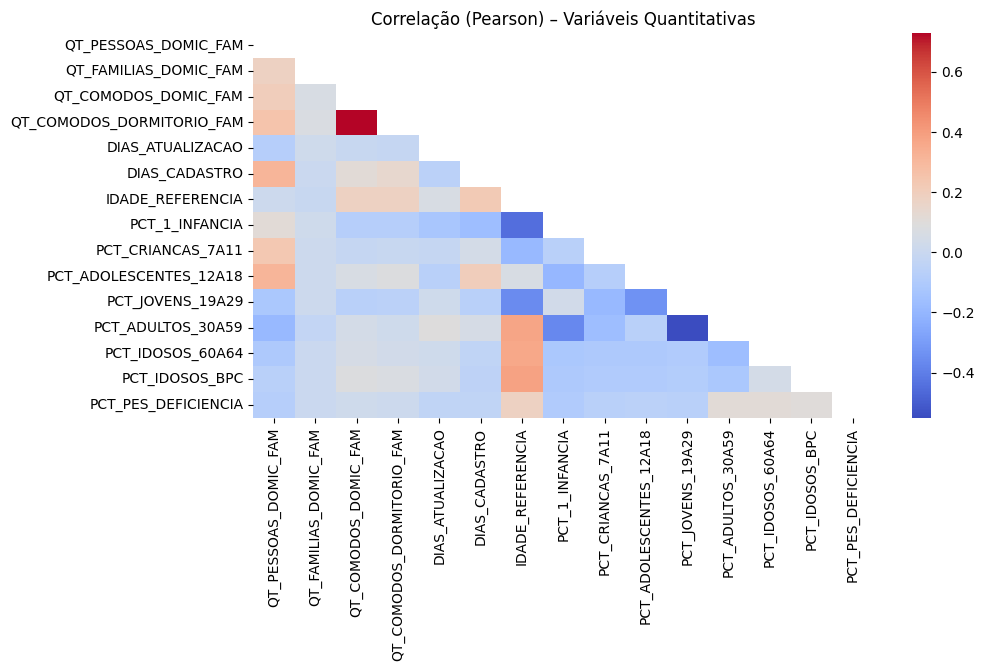

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = df[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


In [9]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
27,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.734603
95,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.554600
69,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.454762
75,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.376080
80,PCT_1_INFANCIA,PCT_ADULTOS_30A59,-0.374503
73,IDADE_REFERENCIA,PCT_ADULTOS_30A59,0.373122
72,IDADE_REFERENCIA,PCT_JOVENS_19A29,-0.364760
74,IDADE_REFERENCIA,PCT_IDOSOS_60A64,0.361708
90,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,-0.338412
4,QT_PESSOAS_DOMIC_FAM,DIAS_CADASTRO,0.311480


In [10]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


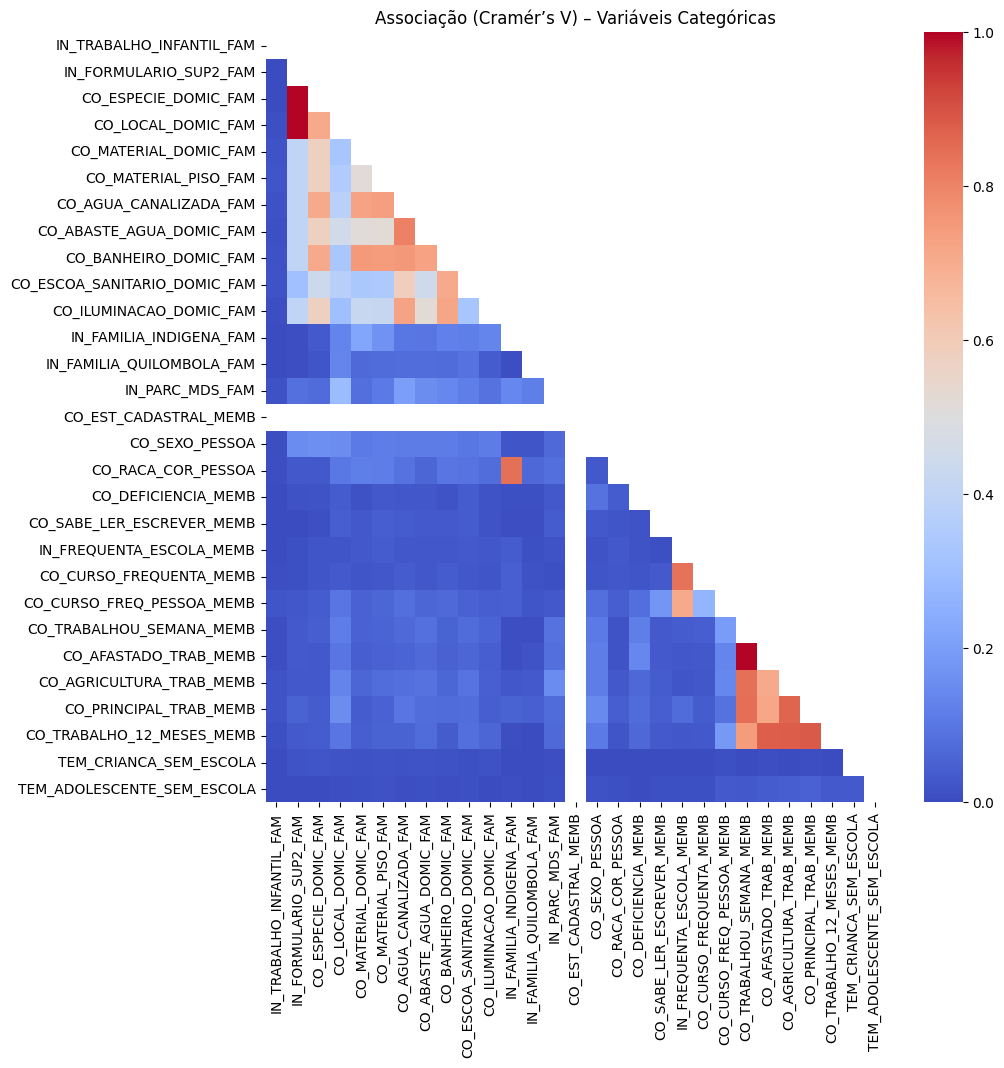

In [11]:
# Selecionar todas as categóricas
df_cat = df[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [12]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   1.000000
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   1.000000
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.886037
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.879521
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.877785
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.864705
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.845238
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.841189
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.840944


In [13]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   1.000000
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   1.000000
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.886037
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.879521
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.877785
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.864705
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.845238
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.841189
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.840944
333  IN_FREQUENTA_ESCOLA_MEMB    CO_CURSO_FREQUENTA_MEMB   0.838597
147    CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.806694


In [14]:
df = df.drop(columns=['IN_FORMULARIO_SUP2_FAM', 'CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'IN_FAMILIA_INDIGENA_FAM', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_AGUA_CANALIZADA_FAM', 'CO_TRABALHO_12_MESES_MEMB'])

In [15]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'DIAS_ATUALIZACAO', 'DIAS_CADASTRO',
       'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA', 'IDADE_REFERENCIA',
       'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
       'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59',
       'PCT_IDOSOS_60A64', 'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA',
 

In [16]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_CRIANCAS_7A11,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,classe_renda
0,6763755,2.0,35,43907,1.0,1.0,1.0,1.0,4,1.0,...,0.0,0.000000,0.0,0.000000,1.0,0.0,0.0,0,0,2
1,3515966,2.0,29,8408,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.666667,0.0,0.333333,0.0,0.0,0.0,0,0,0
2,9250631,2.0,52,5513,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.333333,0.0,0.333333,0.0,0.0,0.0,0,0,1
3,4719309,2.0,32,5002,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.000000,0.5,0.500000,0.0,0.0,0.0,0,0,1
4,5385510,2.0,33,2502,2.0,1.0,1.0,1.0,5,2.0,...,0.0,0.000000,0.5,0.000000,0.0,0.0,0.0,0,0,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID_FAM_ANON                   999999 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      999999 non-null  float64
 2   CO_MUNIC_IBGE_2_FAM           999999 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           999999 non-null  int64  
 4   QT_PESSOAS_DOMIC_FAM          999999 non-null  float64
 5   QT_FAMILIAS_DOMIC_FAM         999999 non-null  float64
 6   CO_ESPECIE_DOMIC_FAM          999999 non-null  float64
 7   CO_LOCAL_DOMIC_FAM            999999 non-null  float64
 8   QT_COMODOS_DOMIC_FAM          999999 non-null  int64  
 9   QT_COMODOS_DORMITORIO_FAM     999999 non-null  float64
 10  CO_MATERIAL_DOMIC_FAM         999999 non-null  int64  
 11  CO_MATERIAL_PISO_FAM          999999 non-null  int64  
 12  CO_ABASTE_AGUA_DOMIC_FAM      999999 non-nul

In [18]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_CRIANCAS_7A11,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,classe_renda
0,6763755,2.0,35,43907,1.0,1.0,1.0,1.0,4,1.0,...,0.0,0.000000,0.0,0.000000,1.0,0.0,0.0,0,0,2
1,3515966,2.0,29,8408,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.666667,0.0,0.333333,0.0,0.0,0.0,0,0,0
2,9250631,2.0,52,5513,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.333333,0.0,0.333333,0.0,0.0,0.0,0,0,1
3,4719309,2.0,32,5002,3.0,1.0,1.0,1.0,5,2.0,...,0.0,0.000000,0.5,0.500000,0.0,0.0,0.0,0,0,1
4,5385510,2.0,33,2502,2.0,1.0,1.0,1.0,5,2.0,...,0.0,0.000000,0.5,0.000000,0.0,0.0,0.0,0,0,0


## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [19]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'DIAS_ATUALIZACAO', 'DIAS_CADASTRO',
       'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA', 'IDADE_REFERENCIA',
       'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
       'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59',
       'PCT_IDOSOS_60A64', 'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA',
 

In [20]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
        'IN_TRABALHO_INFANTIL_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
        'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
        'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 
        'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
        'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
        'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
        'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB'
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
        'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
        'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
        'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
        'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'DIAS_ATUALIZACAO', 'DIAS_CADASTRO',
        'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']

target_col = "classe_renda"
id_col = "ID_FAM_ANON"


In [21]:
# X e y brutos
X = df.drop(columns=[target_col, id_col])
y = df[target_col]

# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['IN_TRABALHO_INFANTIL_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'CO_SEXO_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB']
Multicategóricas: ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB']


In [22]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

In [23]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [24]:
# Pipeline para binárias
pipeline_binary = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ])


In [25]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [26]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [27]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [28]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [30]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM',
                                  'DIAS_ATUALIZACAO', 'DIAS_CADASTRO',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADO...
                                 ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
                                  'CO_MATERIAL_DOMIC_FAM',
                                  'CO_MATERIAL_PISO_FAM',
                                  'CO_ABASTE_AGUA_DOMIC_FAM',
                                  'CO_BANHEIRO_DOMIC_FAM',
                                  'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM',
                                  'CO_RACA_COR_PESSOA',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB',
                                  'CO_AFASTADO_TRAB_MEMB',
                                  'CO_PRINCIPAL_TRAB_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [31]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__DIAS_ATUALIZACAO,quant__DIAS_CADASTRO,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,...,multicat__CO_PRINCIPAL_TRAB_MEMB_4.0,multicat__CO_PRINCIPAL_TRAB_MEMB_5.0,multicat__CO_PRINCIPAL_TRAB_MEMB_6.0,multicat__CO_PRINCIPAL_TRAB_MEMB_7.0,multicat__CO_PRINCIPAL_TRAB_MEMB_8.0,multicat__CO_PRINCIPAL_TRAB_MEMB_9.0,multicat__CO_PRINCIPAL_TRAB_MEMB_10.0,multicat__CO_PRINCIPAL_TRAB_MEMB_11.0,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.05,0.02,0.052083,0.037037,0.276639,0.601590,0.35,0.25,0.0,0.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,21500.0
1,0.02,0.02,0.052083,0.024691,0.952186,0.244939,0.24,0.00,0.0,0.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,50308.0
2,0.03,0.02,0.062500,0.037037,0.403689,0.062639,0.54,0.00,0.0,0.50,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,43.0,7609.0
3,0.02,0.02,0.062500,0.037037,0.147541,0.302915,0.83,0.00,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,9600.0
4,0.03,0.02,0.041667,0.024691,0.396175,0.061473,0.43,0.00,0.0,0.50,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,51009.0


## Pipeline completo (preprocessamento + modelo)

In [32]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'DIAS_ATUALIZACAO',
                                                   'DIAS_CADASTRO',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA...
                                                   'CO_ABASTE_AGUA_DOMIC_FAM',
                                                   'CO_BANHEIRO_DOMIC_FAM',
                                                   'CO_ILUMINACAO_DOMIC_FAM',
                                                   'IN_PARC_MDS_FAM',
                                                   'CO_RACA_COR_PESSOA',
                                                   'CO_CURSO_FREQUENTA_MEMB',
                                                   'CO_CURSO_FREQ_PESSOA_MEMB',
                                                   'CO_AFASTADO_TRAB_MEMB',
                                                   'CO_PRINCIPAL_TRAB_MEMB']),
                                                 ('geo', 'passthrough',
                                                  ['CO_MUNIC_IBGE_2_FAM',
                                                   'CO_MUNIC_IBGE_5_FAM'])])),
                ('model',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

## Avaliação completa do modelo

### Predições do teste

In [33]:
y_pred = pipeline_rf.predict(X_test)
y_proba = pipeline_rf.predict_proba(X_test)  # para AUC

### Acurácia e F1

In [34]:
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"Acurácia: {acc:.3f}")
print(f"F1 macro: {f1_macro:.3f}")
print(f"F1 weighted: {f1_weighted:.3f}")

Acurácia: 0.604
F1 macro: 0.600
F1 weighted: 0.600


### AUC

In [35]:
# Se classe_renda for multiclasse, usamos one-vs-rest
auc_ovr = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"AUC (OVR, weighted): {auc_ovr:.3f}")

AUC (OVR, weighted): 0.793


### Classification report

In [36]:
print("Classification report:")
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

           0       0.63      0.63      0.63     66666
           1       0.50      0.45      0.47     66667
           2       0.67      0.73      0.70     66667

    accuracy                           0.60    200000
   macro avg       0.60      0.60      0.60    200000
weighted avg       0.60      0.60      0.60    200000



### Matriz de confusão

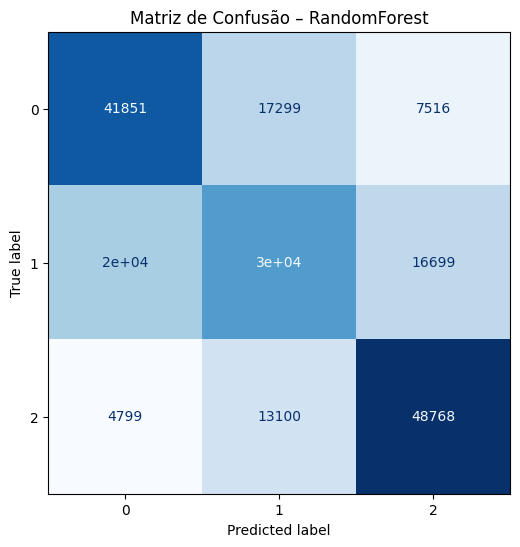

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão – RandomForest")
plt.show()

### Comparando diversos modelos

In [38]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from xgboost import XGBClassifier
from sklearn.base import clone

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, multi_class="auto", n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",  # multi-classe com predict_proba
        eval_metric="mlogloss",
        tree_method="hist",          # mais rápido em bases grandes
        random_state=42,
        n_jobs=-1
    ),
}

results = []

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    # métricas principais
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")
    
    # AUC (se o modelo tiver predict_proba)
    try:
        y_proba = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        auc = np.nan
    
    results.append({
        "modelo": name,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "auc_weighted_ovr": auc
    })

df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
df_results



Treinando modelo: RandomForest

Treinando modelo: LogisticRegression


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Treinando modelo: GradientBoosting

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost


,modelo,accuracy,f1_weighted,f1_macro,auc_weighted_ovr
4,XGBoost,0.618070,0.614244,0.614244,0.807406
3,HistGradientBoosting,0.617295,0.613596,0.613596,0.806156
0,RandomForest,0.603745,0.600266,0.600266,0.792815
2,GradientBoosting,0.602925,0.597390,0.597390,0.791872
1,LogisticRegression,0.553555,0.546223,0.546223,0.738894


## Pipeline processamento + modelo (XGBoost)

In [40]:
pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'DIAS_ATUALIZACAO',
                                                   'DIAS_CADASTRO',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Avaliação completa do Modelo

In [41]:
y_pred = pipeline_xgb.predict(X_test)
y_proba = pipeline_xgb.predict_proba(X_test)  # para AUC

## Acurácia e F1

In [42]:
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"Acurácia: {acc:.3f}")
print(f"F1 macro: {f1_macro:.3f}")
print(f"F1 weighted: {f1_weighted:.3f}")


Acurácia: 0.618
F1 macro: 0.614
F1 weighted: 0.614


### Classification report

In [43]:
print("Classification report:")
print(classification_report(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

           0       0.64      0.65      0.65     66666
           1       0.52      0.46      0.49     66667
           2       0.68      0.75      0.71     66667

    accuracy                           0.62    200000
   macro avg       0.61      0.62      0.61    200000
weighted avg       0.61      0.62      0.61    200000



### Matriz de confusão

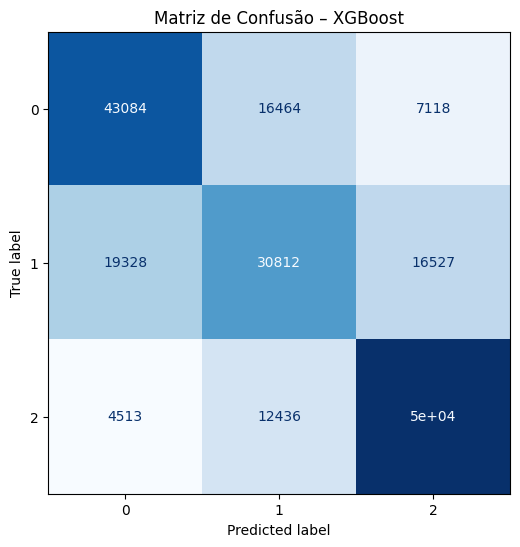

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão – XGBoost")
plt.show()

## Ajustando os parâmetros

### Criando uma amostra estratificada para testar outros parâmetros

In [45]:
from sklearn.model_selection import train_test_split

# usa 30% do X_train só para o tuning 
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.3,
    stratify=y_train,
    random_state=42
)

print(X_tune.shape, y_tune.shape)

(239999, 39) (239999,)


### Modelo base

In [46]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb_base = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1   # paralelismo fica aqui, dentro do modelo
)

pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb_base)
])

### Busca de hiperparâmetros - CV

In [47]:
param_dist = {
    "model__n_estimators": randint(200, 600),
    "model__learning_rate": uniform(0.02, 0.10),   # ~ 0.02 a 0.12
    "model__max_depth": randint(3, 8),
    "model__subsample": uniform(0.6, 0.3),         # ~ 0.6 a 0.9
    "model__colsample_bytree": uniform(0.6, 0.3),  # ~ 0.6 a 0.9
    "model__min_child_weight": randint(1, 6),
    "model__gamma": uniform(0.0, 0.3),
    "model__reg_lambda": uniform(1.0, 8.0),
    "model__reg_alpha": uniform(0.0, 1.5),
}

In [48]:
search = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_dist,
    n_iter=15,              # mais leve que 30
    cv=3,                   # se ainda der memória, pode baixar para 2
    scoring="f1_weighted",  # ou "accuracy"
    verbose=2,
    n_jobs=1,               # ***ponto chave pra evitar estouro de RAM***
    random_state=42
)

search.fit(X_tune, y_tune)

print("Melhor score (CV):", search.best_score_)
print("Melhores parâmetros:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END model__colsample_bytree=0.7123620356542087, model__gamma=0.2852142919229748, model__learning_rate=0.09319939418114051, model__max_depth=7, model__min_child_weight=5, model__n_estimators=302, model__reg_alpha=0.6687491292803867, model__reg_lambda=1.799799326544023, model__subsample=0.7377746675897601; total time=   6.8s
[CV] END model__colsample_bytree=0.7123620356542087, model__gamma=0.2852142919229748, model__learning_rate=0.09319939418114051, model__max_depth=7, model__min_child_weight=5, model__n_estimators=302, model__reg_alpha=0.6687491292803867, model__reg_lambda=1.799799326544023, model__subsample=0.7377746675897601; total time=   6.7s
[CV] END model__colsample_bytree=0.7123620356542087, model__gamma=0.2852142919229748, model__learning_rate=0.09319939418114051, model__max_depth=7, model__min_child_weight=5, model__n_estimators=302, model__reg_alpha=0.6687491292803867, model__reg_lambda=1.799799326544023, model

In [49]:
best_model = search.best_estimator_

# agora treina com 100% do X_train
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")

try:
    y_proba = best_model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except Exception:
    auc = np.nan

print("Resultados no teste:")
print("  accuracy:", acc)
print("  f1_weighted:", f1_w)
print("  f1_macro:", f1_m)
print("  auc_weighted_ovr:", auc)

Resultados no teste:
  accuracy: 0.620305
  f1_weighted: 0.616839346418711
  f1_macro: 0.6168394955447912
  auc_weighted_ovr: 0.8090183188223524


### Busca de hiperparâmetros - manual

In [50]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

# 1) Dicionário com 4 configurações de XGBoost
xgb_configs = {
    # Config 1 – baseline (parecida com a que já funcionou bem)
    "XGB_baseline": {
        "n_estimators": 300,
        "learning_rate": 0.1,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 1,
        "gamma": 0.0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    },

    # Config 2 – mais suave: mais árvores, learning_rate menor
    "XGB_suave": {
        "n_estimators": 600,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 3,
        "gamma": 0.1,
        "reg_lambda": 5.0,
        "reg_alpha": 0.0,
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    },

    # Config 3 – árvores mais rasas, foco em generalização
    "XGB_raso_regularizado": {
        "n_estimators": 700,
        "learning_rate": 0.04,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5,
        "gamma": 0.2,
        "reg_lambda": 8.0,
        "reg_alpha": 0.5,
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    },

    # Config 4 – árvores mais profundas, mais capacidade (aceitando mais risco de overfitting)
    "XGB_profundo": {
        "n_estimators": 400,
        "learning_rate": 0.07,
        "max_depth": 8,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "min_child_weight": 1,
        "gamma": 0.0,
        "reg_lambda": 2.0,
        "reg_alpha": 0.0,
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    }
}

results_xgb = []
best_pipelines = {}  # para guardar os pipelines treinados

for name, params in xgb_configs.items():
    print(f"\nTreinando configuração: {name}")
    
    clf = XGBClassifier(**params)
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # métricas
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")

    # AUC (se conseguir proba)
    try:
        y_proba = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        auc = np.nan

    results_xgb.append({
        "config": name,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "auc_weighted_ovr": auc
    })

    best_pipelines[name] = pipe  # guarda o pipeline treinado

df_results_xgb = pd.DataFrame(results_xgb).sort_values("accuracy", ascending=False)
df_results_xgb



Treinando configuração: XGB_baseline

Treinando configuração: XGB_suave

Treinando configuração: XGB_raso_regularizado

Treinando configuração: XGB_profundo


,config,accuracy,f1_weighted,f1_macro,auc_weighted_ovr
3,XGB_profundo,0.620640,0.617303,0.617303,0.809488
1,XGB_suave,0.618655,0.614822,0.614822,0.807638
0,XGB_baseline,0.618070,0.614244,0.614244,0.807406
2,XGB_raso_regularizado,0.613405,0.608109,0.608110,0.802674


In [51]:
melhor_pipe = best_pipelines["XGB_profundo"]

In [52]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

y_pred = melhor_pipe.predict(X_test)

try:
    y_proba = melhor_pipe.predict_proba(X_test)
except Exception:
    y_proba = None

acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")

if y_proba is not None:
    auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
else:
    auc_weighted = np.nan

print("Resultados no teste (XGB_profundo):")
print("  accuracy:", acc)
print("  f1_weighted:", f1_w)
print("  f1_macro:", f1_m)
print("  auc_weighted_ovr:", auc_weighted)


Resultados no teste (XGB_profundo):
  accuracy: 0.62064
  f1_weighted: 0.6173030059738682
  f1_macro: 0.6173031546814367
  auc_weighted_ovr: 0.8094881367112923


In [53]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

# 1) Relatório detalhado por classe
print("\n=== Relatório por classe (precision, recall, f1, suporte) ===")
print(classification_report(y_test, y_pred, digits=3))

# 2) Matriz de confusão organizada em DataFrame
labels = np.unique(y_test)  # ou melhor_pipe.classes_ se preferir
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(
    cm,
    index=[f"real_{l}" for l in labels],
    columns=[f"pred_{l}" for l in labels]
)

print("\n=== Matriz de confusão ===")
print(cm_df)

# 3) Tabela com métricas por classe (para manipular no Pandas / exportar)
prec, rec, f1_cls, support = precision_recall_fscore_support(
    y_test, y_pred, labels=labels, zero_division=0
)

metrics_df = pd.DataFrame({
    "classe": labels,
    "precision": prec,
    "recall": rec,
    "f1": f1_cls,
    "suporte": support
}).set_index("classe")

print("\n=== Tabela de métricas por classe ===")
print(metrics_df)

# 4) AUC por classe (one-vs-rest), se houver predict_proba
if y_proba is not None:
    # Garante mesma ordem de classes
    classes = melhor_pipe.classes_ if hasattr(melhor_pipe, "classes_") else labels

    # Binariza y_test para cálculo de AUC por classe
    y_test_bin = label_binarize(y_test, classes=classes)

    auc_por_classe = {}
    for i, cls in enumerate(classes):
        try:
            auc_cls = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
            auc_por_classe[cls] = auc_cls
        except ValueError:
            # Caso alguma classe não apareça no y_test
            auc_por_classe[cls] = np.nan

    print("\n=== AUC (one-vs-rest) por classe ===")
    for cls, val in auc_por_classe.items():
        if np.isnan(val):
            print(f"  Classe {cls}: AUC não calculável (classe ausente no y_test)")
        else:
            print(f"  Classe {cls}: {val:.4f}")
else:
    print("\nSem predict_proba disponível: AUC por classe não será calculado.")



=== Relatório por classe (precision, recall, f1, suporte) ===
              precision    recall  f1-score   support

           0      0.649     0.645     0.647     66666
           1      0.517     0.471     0.493     66667
           2      0.681     0.746     0.712     66667

    accuracy                          0.621    200000
   macro avg      0.616     0.621     0.617    200000
weighted avg      0.616     0.621     0.617    200000


=== Matriz de confusão ===
        pred_0  pred_1  pred_2
real_0   43022   16735    6909
real_1   18897   31387   16383
real_2    4395   12553   49719

=== Tabela de métricas por classe ===
        precision    recall        f1  suporte
classe                                        
0        0.648762  0.645336  0.647045    66666
1        0.517297  0.470803  0.492956    66667
2        0.680980  0.745781  0.711909    66667

=== AUC (one-vs-rest) por classe ===
  Classe 0: 0.8360
  Classe 1: 0.7147
  Classe 2: 0.8778


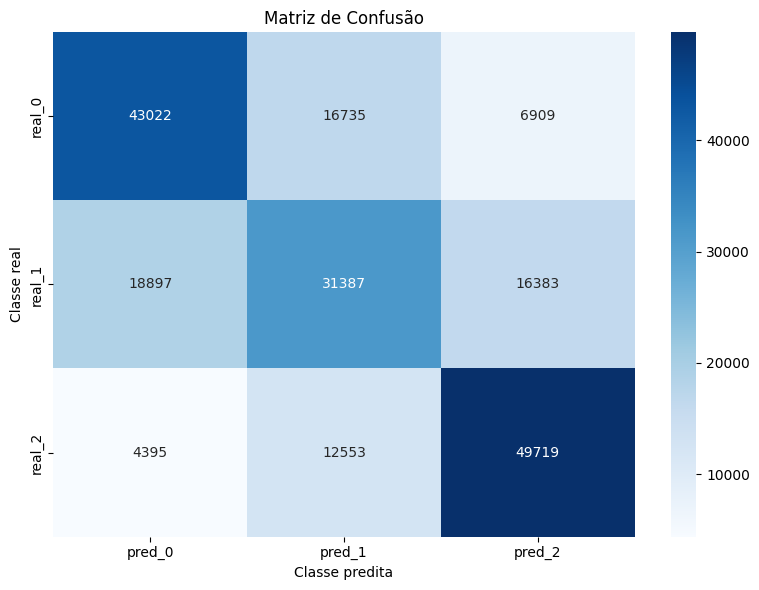

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão")
plt.ylabel("Classe real")
plt.xlabel("Classe predita")
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

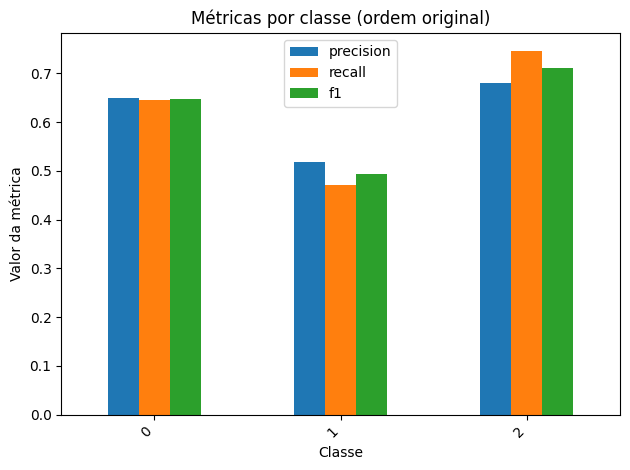

In [59]:
metrics_plot = metrics_df.copy()  # mantém a ordem original

plt.figure(figsize=(10, 6))
metrics_plot[["precision", "recall", "f1"]].plot(kind="bar")
plt.title("Métricas por classe (ordem original)")
plt.ylabel("Valor da métrica")
plt.xlabel("Classe")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



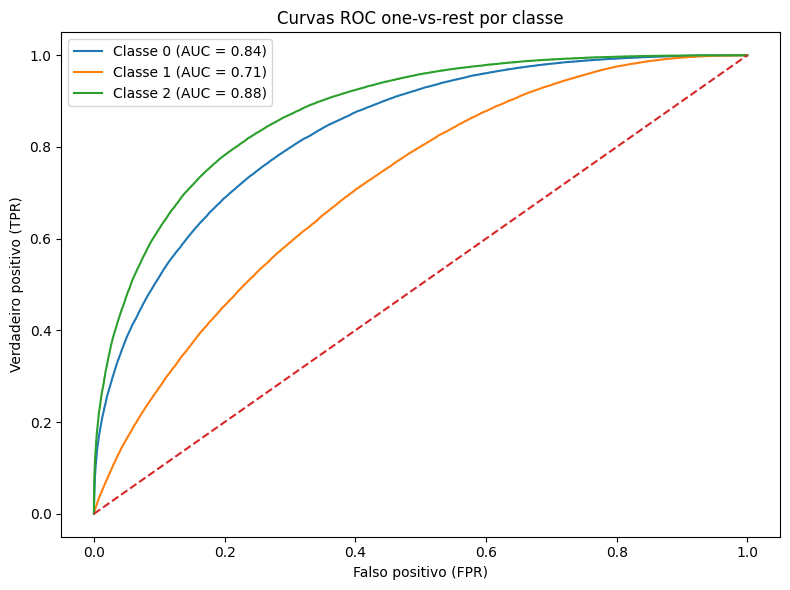

In [56]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

if y_proba is not None:
    classes = melhor_pipe.classes_
    y_test_bin = label_binarize(y_test, classes=classes)

    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(classes):
        # ignora classe que não aparece no y_test
        if y_test_bin[:, i].sum() == 0:
            continue
        
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Classe {cls} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--")  # linha aleatória
    plt.xlabel("Falso positivo (FPR)")
    plt.ylabel("Verdadeiro positivo (TPR)")
    plt.title("Curvas ROC one-vs-rest por classe")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Sem predict_proba, não dá para gerar curvas ROC.")


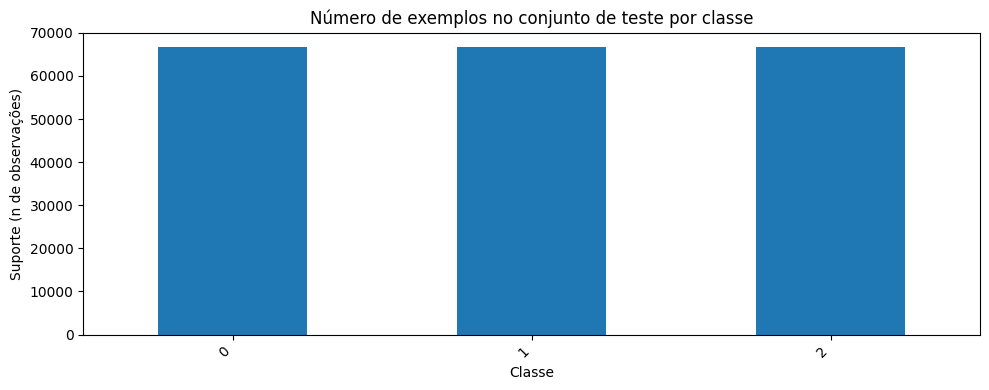

In [58]:
plt.figure(figsize=(10, 4))
metrics_df["suporte"].plot(kind="bar")
plt.title("Número de exemplos no conjunto de teste por classe")
plt.ylabel("Suporte (n de observações)")
plt.xlabel("Classe")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



## Análise das variáveis

In [60]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# calcula a importância por permutação no conjunto de teste
result = permutation_importance(
    melhor_pipe,
    X_test,
    y_test,
    n_repeats=5,           
    scoring="f1_weighted", 
    n_jobs=1,
    random_state=42
)

# importância média por feature
importances_mean = result.importances_mean
importances_std = result.importances_std

# monta um DataFrame com as importâncias
df_importances = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importances_mean,
    "importance_std": importances_std
}).sort_values("importance_mean", ascending=False)

df_importances.head(20)

,feature,importance_mean,importance_std
17,DIAS_ATUALIZACAO,0.071426,0.000511
33,PCT_ADULTOS_30A59,0.036896,0.000449
27,CO_AFASTADO_TRAB_MEMB,0.026800,0.000498
28,CO_PRINCIPAL_TRAB_MEMB,0.023353,0.000455
18,DIAS_CADASTRO,0.018747,0.000293
29,PCT_1_INFANCIA,0.017569,0.000675
1,CO_MUNIC_IBGE_2_FAM,0.012095,0.000300
31,PCT_ADOLESCENTES_12A18,0.011437,0.000289
35,PCT_IDOSOS_BPC,0.010696,0.000074
30,PCT_CRIANCAS_7A11,0.009727,0.000328


In [ ]:
top_n = 20
top_features = df_importances.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation importance (média da queda no score)")
plt.title("Top variáveis mais importantes – XGB_profundo")
plt.grid(axis="x")
plt.show()